first 5 rows :    Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SaleP

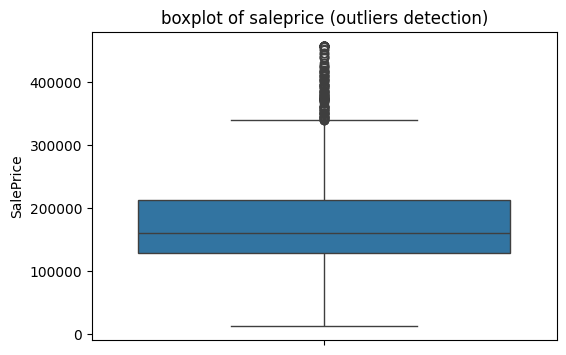

missing in saleprice: 0
Duplicates: 0
min saleprice: 12789.0


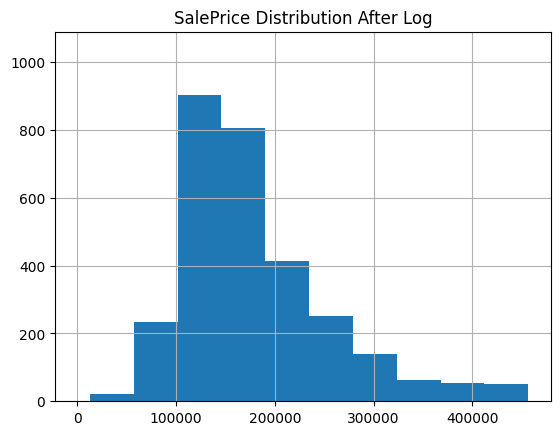

In [2]:
! pip install import-ipynb
import import_ipynb
import Phase2_
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path= "/content/AmesHousing.csv"
df = pd.read_csv(path)
from Phase2_ import clean_data
df= clean_data(df)
df.columns

missing in saleprice: 0
Duplicates: 0
min saleprice: 12789.0


Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

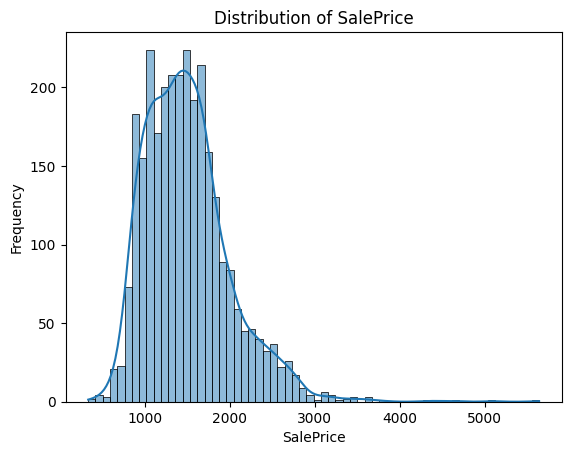

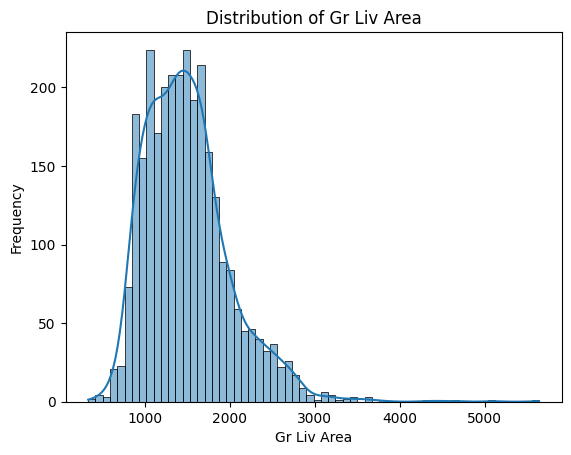

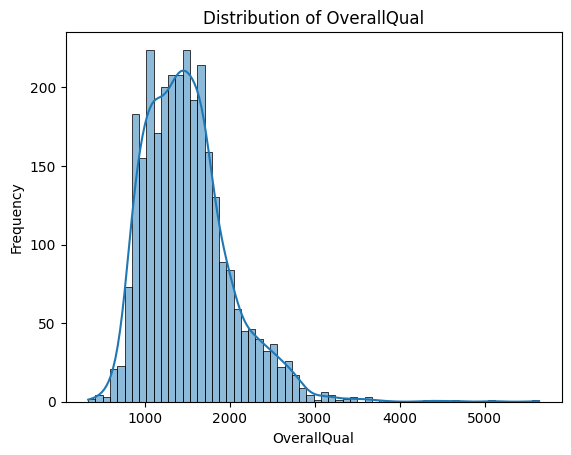

In [9]:
#define target and numerical columns
target = "SalePrice"
num_cols = ["SalePrice" ,"Gr Liv Area","OverallQual" ]
#plot distribution for each numerical columns
for col in num_cols:
  plt.figure()
  sns.histplot(df["Gr Liv Area"], kde=True)
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt,plt.ylabel("Frequency")
  plt.show
  #insight : describe shape (skewed or normal)

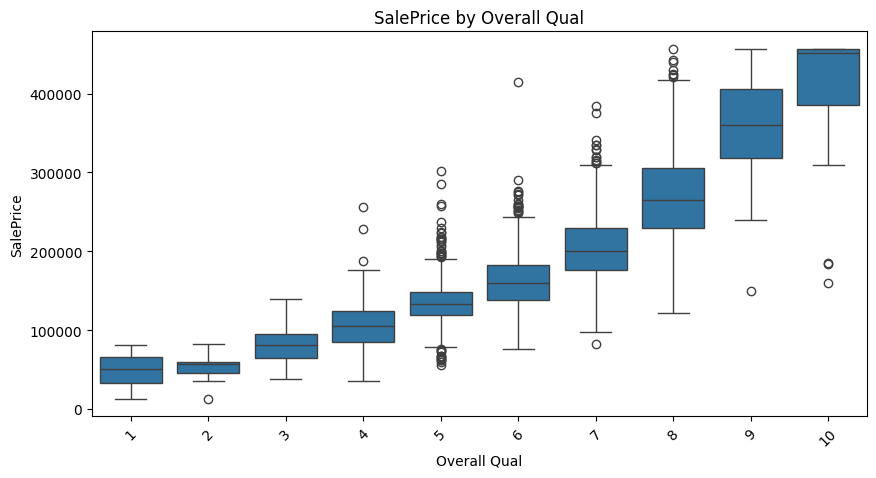

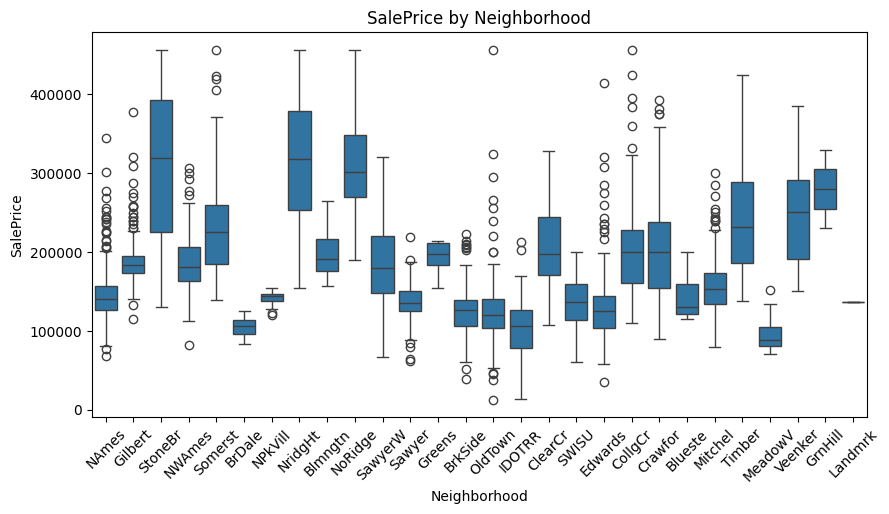

In [11]:
#compare target across categories
cat_cols = ["Overall Qual", "Neighborhood"]

for col in cat_cols:
  plt.figure(figsize=(10,5))
  sns.boxplot(x=df[col], y=df[target])
  plt.xticks(rotation=45)
  plt.title(f"{target} by {col}")
  plt.show
  # insight : explain which category has higher price

<function matplotlib.pyplot.show(close=None, block=None)>

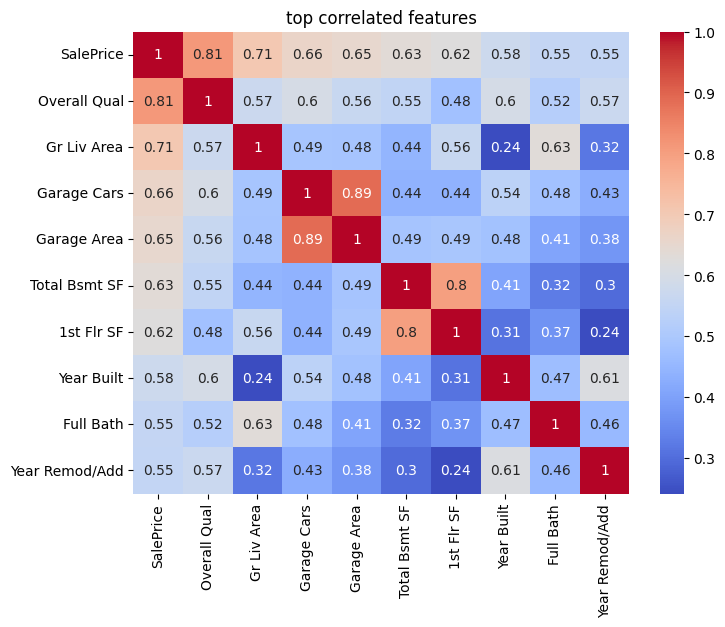

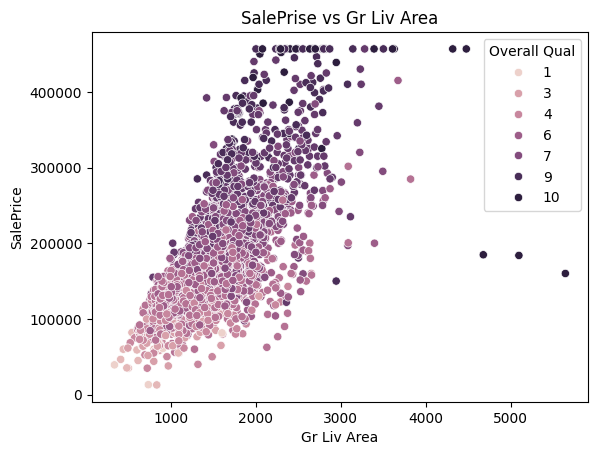

In [19]:
#compute correlation matrix
corr = df.corr(numeric_only= True)
# get top 10 features correlated with target
top_corr = corr[target].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(8,6))
sns.heatmap(df[top_corr].corr() ,annot =True , cmap="coolwarm")
plt.title("top correlated features")
plt.show
# insight : identify strongest featrue

#scatter plot with third varible
plt.figure()
sns.scatterplot(
    x=df["Gr Liv Area"],
    y=df["SalePrice"],
     hue=df["Overall Qual"] ,
)
plt.title("SalePrise vs Gr Liv Area")
plt.show

In [23]:
#groupby analysis
grouped = df.groupby("Neighborhood")[target].mean().sort_values(ascending=False)
print(grouped.head())
print(grouped.tail())
#convert to numpy array
y=df[target].values
#compute mean manually
mean_manual = np.sum(y) / len(y)
#compute std manually
std_manual = np.sqrt(np.sum((y - mean_manual)**2) / len(y))
print("mean:" , mean_manual)
print("std:" , std_manual)
# standardize manually
Z_manual = (y - mean_manual) / std_manual
print(Z_manual [:5])
#compare with sklearn
scaler = StandardScaler()
Z_sklearn = scaler.fit_transform(y.reshape(-1,1))

#insight : checkcif results are similar

from numpy.linalg import norm

high = df.loc[df[target].idxmax()]
low = df.loc[df[target].idxmin()]

num_cols = df.select_dtypes(include=np.number).columns

high_vec = high[num_cols].values
low_vec  = low[num_cols].values

cos_sim = np.dot(high_vec, low_vec) / (norm(high_vec) * norm(low_vec))
print(cos_sim)


Neighborhood
NoRidge    317746.335915
NridgHt    316136.356506
StoneBr    313596.940392
GrnHill    280000.000000
Veenker    248314.583333
Name: SalePrice, dtype: float64
Neighborhood
BrkSide    124756.250000
OldTown    123915.181464
BrDale     105608.333333
IDOTRR     103752.903226
MeadowV     95756.486486
Name: SalePrice, dtype: float64
mean: 179956.70481228668
std: 76061.61121141634
[ 0.46072249 -0.98547353 -0.10460868  0.84199236  0.13072685]
0.8363774690925958


In [25]:
#define threshold (75th percentile)
threshold = df[target].quantile(0.75)
#filter high quality houses
high_quality = df[df["Overall Qual"]>=8]

prob = (high_quality[target] > threshold).mean()
print("Probability:", prob)

Probability: 0.8729508196721312


<function matplotlib.pyplot.show(close=None, block=None)>

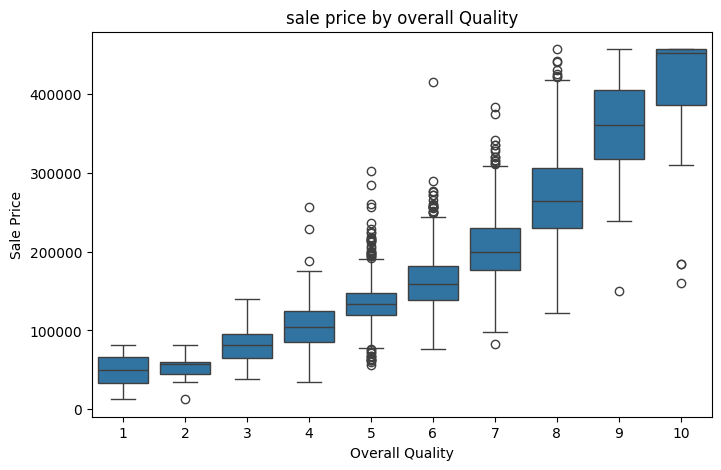

In [28]:
#Houses with higher overall quality tend to have higher sale prices.
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Overall Qual"], y="SalePrice", data=df)
plt.title("sale price by overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.show